In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# === Case setup ===
case_ids = ['0p375', '0p95', '1p53', '3p75', '9p4']

# === Load all reference data files once ===
df_exp = pd.read_csv('/home/d/Downloads/rs_fig7_exp.csv')
df_mvp = pd.read_csv('/home/d/Downloads/transverse_fig7.csv')

# === Create subplots: 1 row, 5 columns ===
fig, axes = plt.subplots(1, 5, figsize=(18, 6), sharey=True)

for i, case in enumerate(case_ids):
    ax = axes[i]

    # --- kOmegaSST simulation ---
    sim_file = f'/home/d/ssh_files/rms/{case}.csv'
    df_sim = pd.read_csv(sim_file)
    df_sim = df_sim[['Points:2', 'UPrime2Mean:4']]
    df_sim['ReStress'] = df_sim['UPrime2Mean:4']
    df_avg = df_sim.groupby('Points:2', as_index=False)['ReStress'].mean()

    z_norm = df_avg['Points:2'] / 0.04
    re_norm = df_avg['ReStress'] / (16.6**2)

    # --- Experimental data ---
    x_exp = df_exp[f'{case}_x']
    y_exp = df_exp[f'{case}_y']

    # --- MVP data ---
    x_mvp = df_mvp[f'rrs{case}_x']
    y_mvp = df_mvp[f'rrs{case}_y']
    df_mvp_case = pd.DataFrame({'x': x_mvp, 'y': y_mvp}).dropna().sort_values(by='y')

    # --- Plot curves ---
    ax.plot(df_mvp_case['x'], df_mvp_case['y'], marker='s', linestyle='-', label='MVP', color='red', zorder=1)
    ax.plot(re_norm, z_norm, marker='o', linestyle='-', label='kOmegaSST', color='blue', zorder=2)
    ax.plot(x_exp, y_exp, marker='x', linestyle='--', label='Experimental', color='black', zorder=3)

    ax.set_title(f'{case}')
    ax.set_xlim(-0.3, 0.3)
    ax.set_ylim(-1.5, 1.5)
    ax.set_xticks(np.linspace(-0.3, 0.3, 5))
    ax.set_yticks(np.arange(-1.5, 1.6, 0.5))
    ax.grid(True)

    if i == 0:
        ax.set_ylabel('z / 0.04')
    ax.set_xlabel("Reynolds Stress / 16.6²")

# === Add common legend just once (bottom center) ===
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize='medium', frameon=False)

plt.tight_layout(rect=[0, 0.05, 1, 1])  # make space for legend
plt.show()


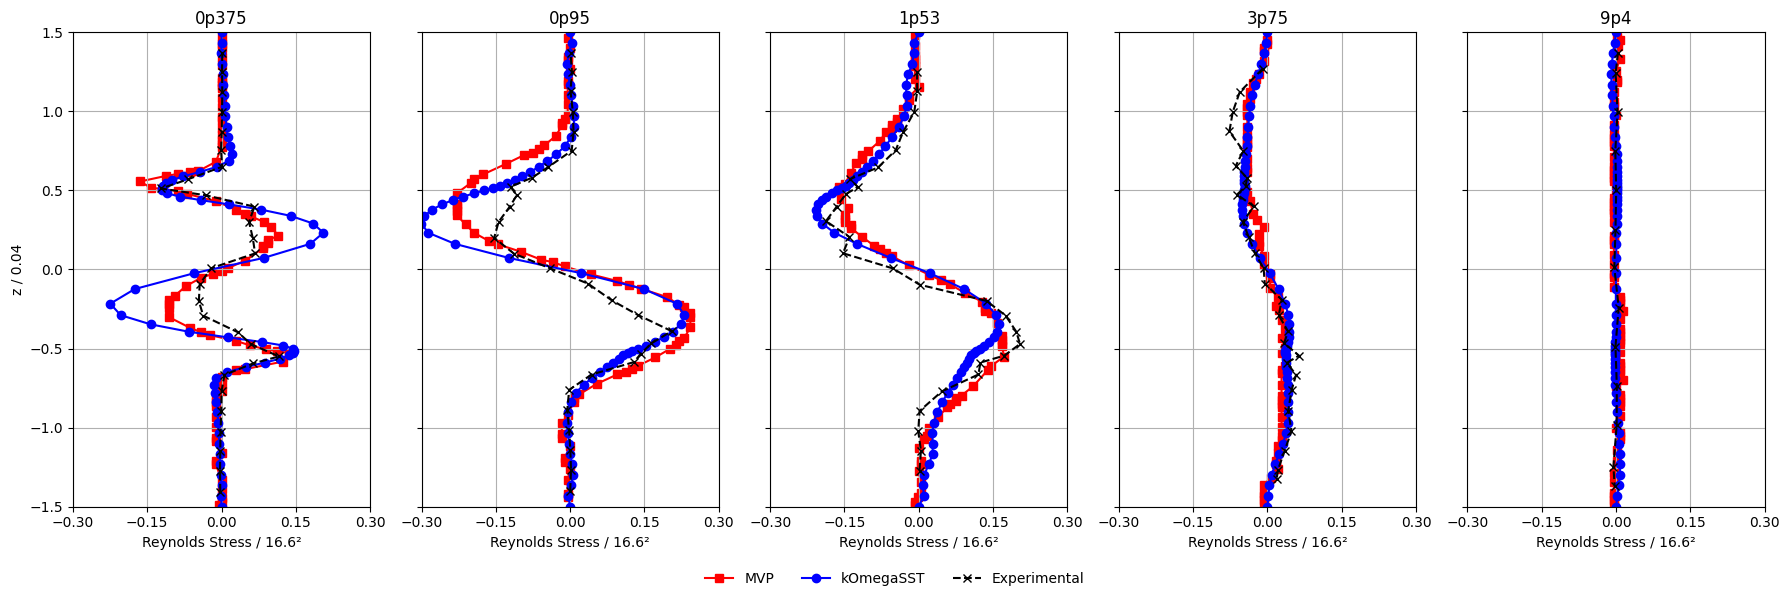

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# === Case setup ===
case_ids = ['0p375', '0p95', '1p53', '3p75', '9p4']

# === Load all reference data files once ===
df_exp = pd.read_csv('/home/d/Downloads/rs_fig7_exp.csv')
df_mvp = pd.read_csv('/home/d/Downloads/transverse_fig7.csv')

# === Create subplots: 1 row, 5 columns ===
fig, axes = plt.subplots(1, 5, figsize=(18, 6), sharey=True)

for i, case in enumerate(case_ids):
    ax = axes[i]

    # --- kOmegaSST simulation ---
    sim_file = f'/home/d/ssh_files/rms7_15/{case}.csv'
    df_sim = pd.read_csv(sim_file)
    df_sim = df_sim[['Points:2', 'UPrime2Mean:4']]
    df_sim['ReStress'] = df_sim['UPrime2Mean:4']
    df_avg = df_sim.groupby('Points:2', as_index=False)['ReStress'].mean()

    z_norm = df_avg['Points:2'] / 0.04
    re_norm = df_avg['ReStress'] / (16.6**2)

    # --- Experimental data ---
    x_exp = df_exp[f'{case}_x']
    y_exp = df_exp[f'{case}_y']

    # --- MVP data ---
    x_mvp = df_mvp[f'rrs{case}_x']
    y_mvp = df_mvp[f'rrs{case}_y']
    df_mvp_case = pd.DataFrame({'x': x_mvp, 'y': y_mvp}).dropna().sort_values(by='y')

    # --- Plot curves ---
    ax.plot(df_mvp_case['x'], df_mvp_case['y'], marker='s', linestyle='-', label='MVP', color='red', zorder=1)
    ax.plot(re_norm, z_norm, marker='o', linestyle='-', label='kOmegaSST', color='blue', zorder=2)
    ax.plot(x_exp, y_exp, marker='x', linestyle='--', label='Experimental', color='black', zorder=3)

    ax.set_title(f'{case}')
    ax.set_xlim(-0.3, 0.3)
    ax.set_ylim(-1.5, 1.5)
    ax.set_xticks(np.linspace(-0.3, 0.3, 5))
    ax.set_yticks(np.arange(-1.5, 1.6, 0.5))
    ax.grid(True)

    if i == 0:
        ax.set_ylabel('z / 0.04')
    ax.set_xlabel("Reynolds Stress / 16.6²")

# === Add common legend just once (bottom center) ===
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize='medium', frameon=False)

plt.tight_layout(rect=[0, 0.05, 1, 1])  # make space for legend
plt.show()


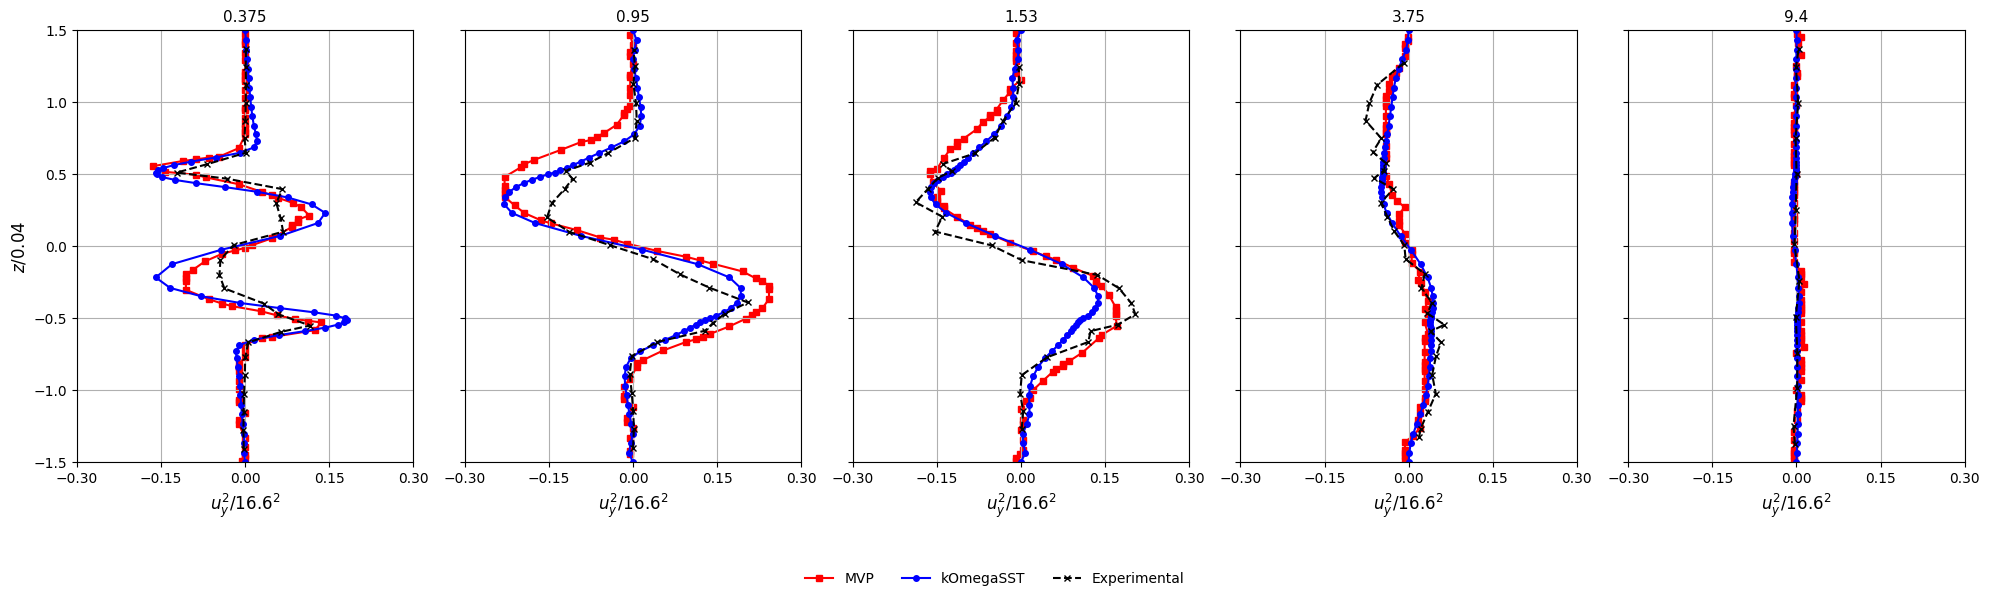


=== Error Metrics ===
Case		MAE		RMSE
0.375		0.0358		0.0496
0.95		0.0229		0.0350
1.53		0.0243		0.0352
3.75		0.0119		0.0151
9.4		0.0025		0.0032


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# === Case setup ===
case_ids = ['0p375', '0p95', '1p53', '3p75', '9p4']

# === Load all reference data files once ===
df_exp = pd.read_csv('/home/d/Downloads/rs_fig7_exp.csv')
df_mvp = pd.read_csv('/home/d/Downloads/transverse_fig7.csv')

# === Create subplots: 1 row, 5 columns ===
fig, axes = plt.subplots(1, 5, figsize=(20, 6), sharey=True)

# === Collect errors to print later ===
error_table = []

for i, case in enumerate(case_ids):
    ax = axes[i]

    # --- kOmegaSST simulation ---
    sim_file = f'/home/d/ssh_files/rms/{case}.csv'
    df_sim = pd.read_csv(sim_file)
    df_sim = df_sim[['Points:2', 'UPrime2Mean:4']]
    df_sim['ReStress'] = df_sim['UPrime2Mean:4']
    df_avg = df_sim.groupby('Points:2', as_index=False)['ReStress'].mean()

    z_norm = df_avg['Points:2'] / 0.04
    re_norm = df_avg['ReStress'] / (16.6**2)

    # --- Experimental data ---
    x_exp = df_exp[f'{case}_x']
    y_exp = df_exp[f'{case}_y']
    df_exp_case = pd.DataFrame({'x': x_exp, 'y': y_exp}).dropna().sort_values(by='y')

    # Interpolation safety check
    mae, rmse = np.nan, np.nan
    try:
        # Interpolate experimental to sim z locations
        exp_interp = np.interp(z_norm, df_exp_case['y'], df_exp_case['x'])

        # Drop any potential NaNs
        valid_mask = ~np.isnan(exp_interp) & ~np.isnan(re_norm)
        mae = mean_absolute_error(exp_interp[valid_mask], re_norm[valid_mask])
        rmse = np.sqrt(mean_squared_error(exp_interp[valid_mask], re_norm[valid_mask]))

    except Exception as e:
        print(f"Interpolation failed for case {case}: {e}")

    error_table.append((case.replace('p', '.'), mae, rmse))

    # --- MVP data ---
    x_mvp = df_mvp[f'rrs{case}_x']
    y_mvp = df_mvp[f'rrs{case}_y']
    df_mvp_case = pd.DataFrame({'x': x_mvp, 'y': y_mvp}).dropna().sort_values(by='y')

    # --- Plot curves ---
    ax.plot(df_mvp_case['x'], df_mvp_case['y'], marker='s', linestyle='-', label='MVP', color='red', zorder=1, markersize=4)
    ax.plot(re_norm, z_norm, marker='o', linestyle='-', label='kOmegaSST', color='blue', zorder=2, markersize=4)
    ax.plot(df_exp_case['x'], df_exp_case['y'], marker='x', linestyle='--', label='Experimental', color='black', zorder=3, markersize=5)

    # Format title (only case name)
    title = case.replace('p', '.')
    ax.set_title(title, fontsize=11)

    ax.set_xlim(-0.3, 0.3)
    ax.set_ylim(-1.5, 1.5)
    ax.set_xticks(np.linspace(-0.3, 0.3, 5))
    ax.set_yticks(np.arange(-1.5, 1.6, 0.5))
    ax.grid(True)

    if i == 0:
        ax.set_ylabel(r'$z / 0.04$', fontsize=12)
    ax.set_xlabel(r'$u_y^2 / 16.6^2$', fontsize=12)

# === Add common legend just once (bottom center) ===
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize='medium', frameon=False)

# === Save and show ===
plt.tight_layout(rect=[0, 0.1, 1, 1])  # leave space for legend
fig.savefig('/home/d/ssh_files/transient2_kOmegaSST_2/fig7_rms_comparison.png', dpi=300)
plt.show()

# === Print MAE and RMSE values ===
print("\n=== Error Metrics ===")
print("Case\t\tMAE\t\tRMSE")
for case, mae, rmse in error_table:
    print(f"{case}\t\t{mae:.4f}\t\t{rmse:.4f}")


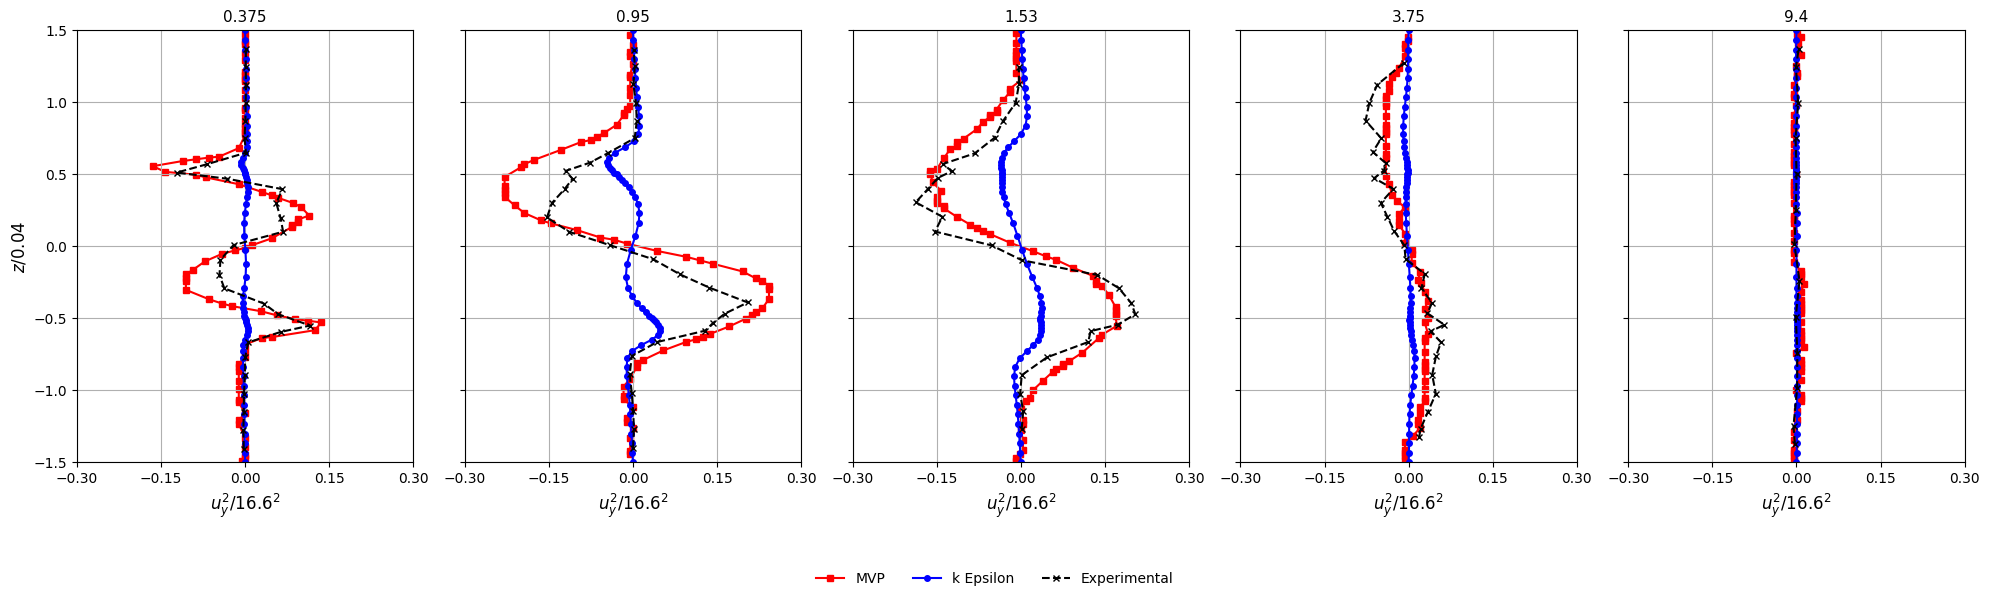


=== Error Metrics ===
Case		MAE		RMSE
0.375		0.0324		0.0477
0.95		0.0569		0.0818
1.53		0.0747		0.0936
3.75		0.0369		0.0400
9.4		0.0016		0.0022


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# === Case setup ===
case_ids = ['0p375', '0p95', '1p53', '3p75', '9p4']

# === Load all reference data files once ===
df_exp = pd.read_csv('/home/d/Downloads/rs_fig7_exp.csv')
df_mvp = pd.read_csv('/home/d/Downloads/transverse_fig7.csv')

# === Create subplots: 1 row, 5 columns ===
fig, axes = plt.subplots(1, 5, figsize=(20, 6), sharey=True)

# === Collect errors to print later ===
error_table = []

for i, case in enumerate(case_ids):
    ax = axes[i]

    # --- kOmegaSST simulation ---
    sim_file = f'/home/d/ssh_files/new_kEp/{case}.csv'
    df_sim = pd.read_csv(sim_file)
    df_sim = df_sim[['Points:2', 'UPrime2Mean:4']]
    df_sim['ReStress'] = df_sim['UPrime2Mean:4']
    df_avg = df_sim.groupby('Points:2', as_index=False)['ReStress'].mean()

    z_norm = df_avg['Points:2'] / 0.04
    re_norm = df_avg['ReStress'] / (16.6**2)

    # --- Experimental data ---
    x_exp = df_exp[f'{case}_x']
    y_exp = df_exp[f'{case}_y']
    df_exp_case = pd.DataFrame({'x': x_exp, 'y': y_exp}).dropna().sort_values(by='y')

    # Interpolation safety check
    mae, rmse = np.nan, np.nan
    try:
        # Interpolate experimental to sim z locations
        exp_interp = np.interp(z_norm, df_exp_case['y'], df_exp_case['x'])

        # Drop any potential NaNs
        valid_mask = ~np.isnan(exp_interp) & ~np.isnan(re_norm)
        mae = mean_absolute_error(exp_interp[valid_mask], re_norm[valid_mask])
        rmse = np.sqrt(mean_squared_error(exp_interp[valid_mask], re_norm[valid_mask]))

    except Exception as e:
        print(f"Interpolation failed for case {case}: {e}")

    error_table.append((case.replace('p', '.'), mae, rmse))

    # --- MVP data ---
    x_mvp = df_mvp[f'rrs{case}_x']
    y_mvp = df_mvp[f'rrs{case}_y']
    df_mvp_case = pd.DataFrame({'x': x_mvp, 'y': y_mvp}).dropna().sort_values(by='y')

    # --- Plot curves ---
    ax.plot(df_mvp_case['x'], df_mvp_case['y'], marker='s', linestyle='-', label='MVP', color='red', zorder=1, markersize=4)
    ax.plot(re_norm, z_norm, marker='o', linestyle='-', label='k Epsilon', color='blue', zorder=2, markersize=4)
    ax.plot(df_exp_case['x'], df_exp_case['y'], marker='x', linestyle='--', label='Experimental', color='black', zorder=3, markersize=5)

    # Format title (only case name)
    title = case.replace('p', '.')
    ax.set_title(title, fontsize=11)

    ax.set_xlim(-0.3, 0.3)
    ax.set_ylim(-1.5, 1.5)
    ax.set_xticks(np.linspace(-0.3, 0.3, 5))
    ax.set_yticks(np.arange(-1.5, 1.6, 0.5))
    ax.grid(True)

    if i == 0:
        ax.set_ylabel(r'$z / 0.04$', fontsize=12)
    ax.set_xlabel(r'$u_y^2 / 16.6^2$', fontsize=12)

# === Add common legend just once (bottom center) ===
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize='medium', frameon=False)

# === Save and show ===
plt.tight_layout(rect=[0, 0.1, 1, 1])  # leave space for legend
fig.savefig('/home/d/ssh_files/transient2_kEpsilon/fig7_rms_comparison.png', dpi=300)
plt.show()

# === Print MAE and RMSE values ===
print("\n=== Error Metrics ===")
print("Case\t\tMAE\t\tRMSE")
for case, mae, rmse in error_table:
    print(f"{case}\t\t{mae:.4f}\t\t{rmse:.4f}")
